In [36]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import warnings
from tqdm.notebook import tqdm 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, array_to_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

warnings.filterwarnings('ignore')


In [3]:
BASE_DIR = r"C:\Users\Gani\Desktop\my_projects\ML_Portfolio\Computer_vision\GAN\data"

In [11]:
image_path = []
for image_name in os.listdir(BASE_DIR):
    full_path = os.path.join(BASE_DIR, image_name)
    if os.path.isfile(full_path):
        image_path.append(full_path) 

In [12]:
image_path[:5]

['C:\\Users\\Gani\\Desktop\\my_projects\\ML_Portfolio\\Computer_vision\\GAN\\data\\1.png',
 'C:\\Users\\Gani\\Desktop\\my_projects\\ML_Portfolio\\Computer_vision\\GAN\\data\\10.png',
 'C:\\Users\\Gani\\Desktop\\my_projects\\ML_Portfolio\\Computer_vision\\GAN\\data\\100.png',
 'C:\\Users\\Gani\\Desktop\\my_projects\\ML_Portfolio\\Computer_vision\\GAN\\data\\1000.png',
 'C:\\Users\\Gani\\Desktop\\my_projects\\ML_Portfolio\\Computer_vision\\GAN\\data\\10000.png']

In [6]:
len(image_path)

21551

## Visualizing dataset

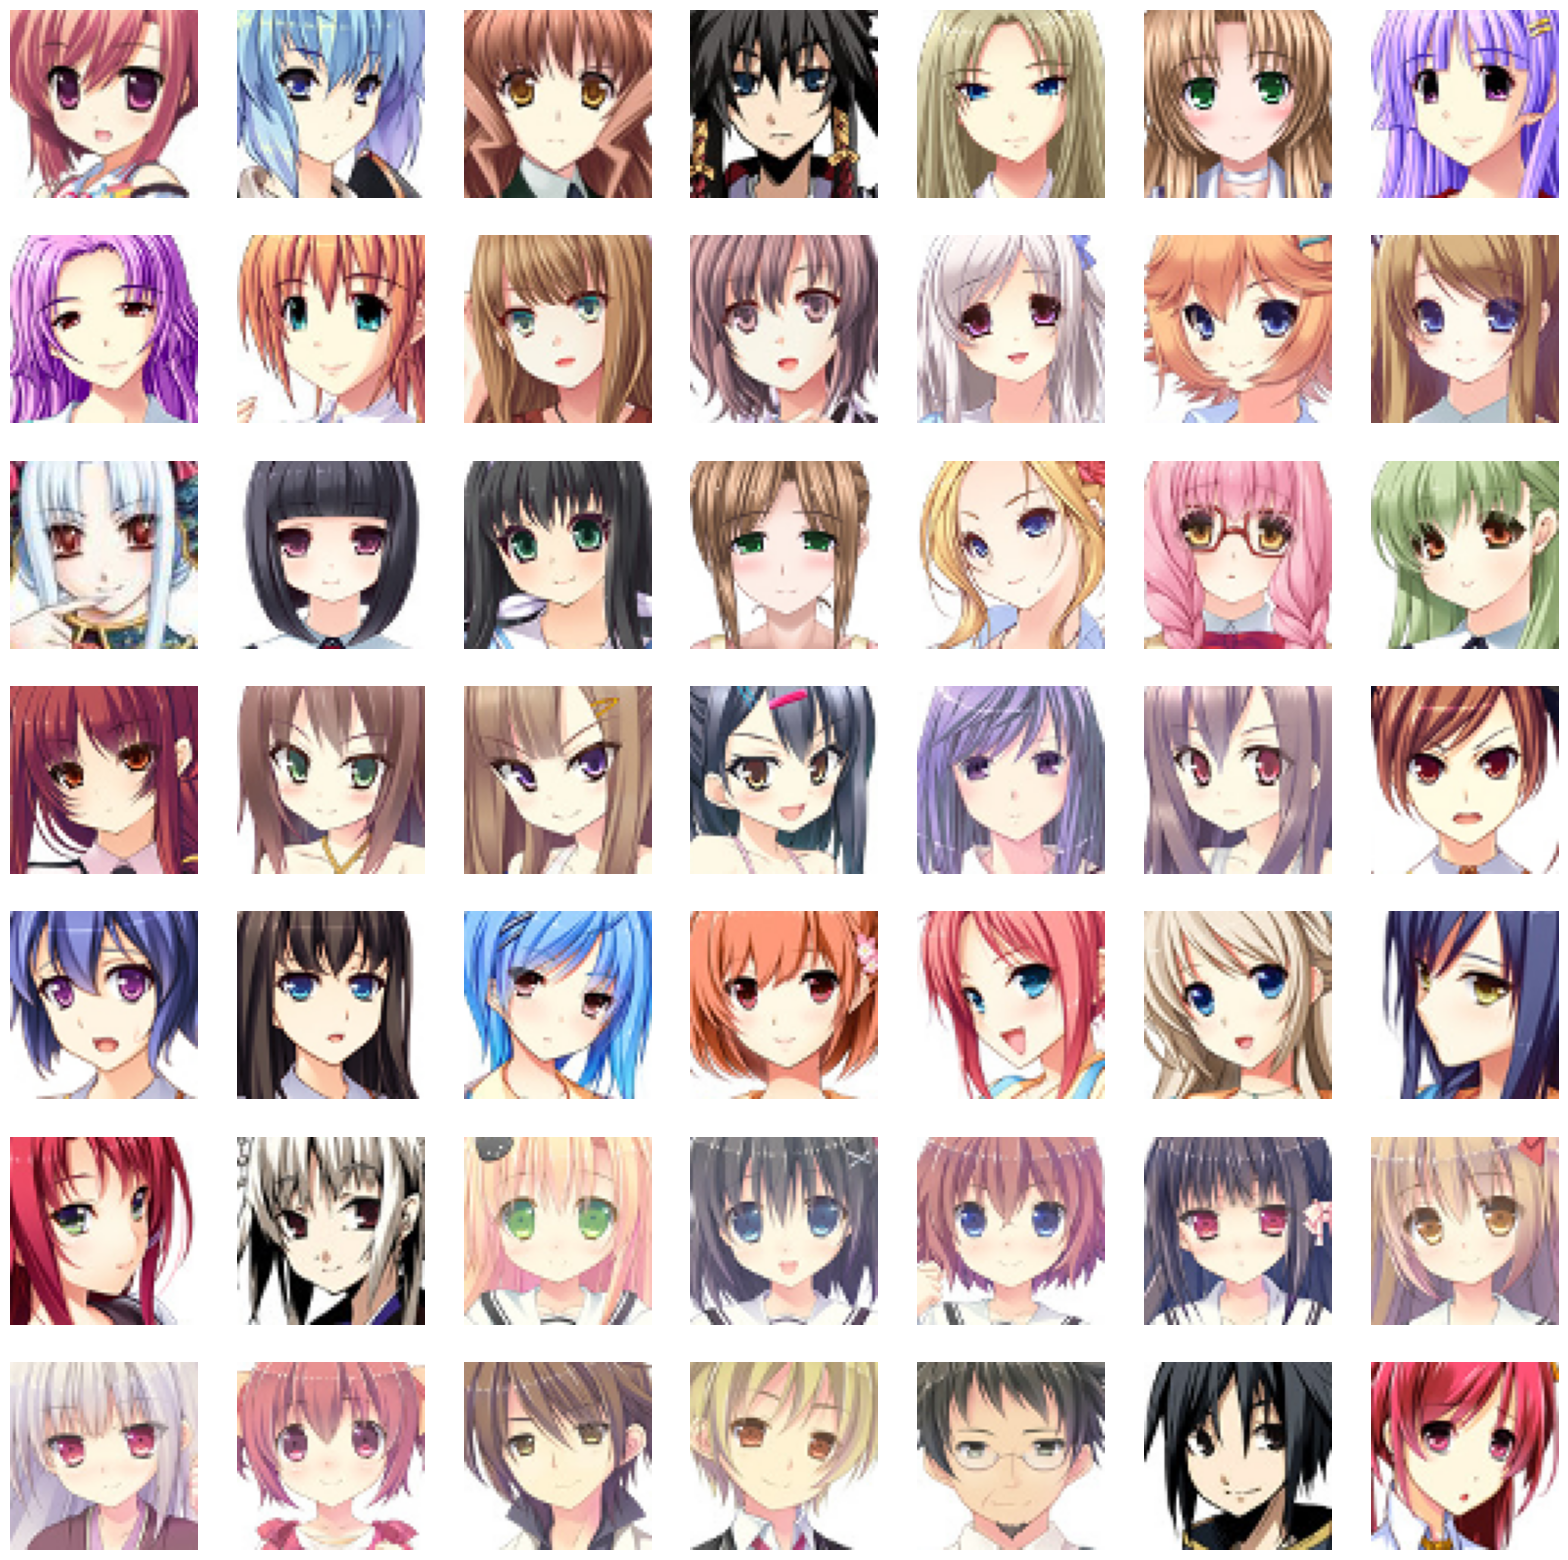

In [7]:
plt.figure(figsize=(20, 20))
temp_images = image_path[:49]
index = 1 

for image_path in temp_images:
    plt.subplot(7, 7, index)
    img = (load_img(image_path))
    img = np.array(img)
    plt.imshow(img)
    plt.axis('off')
    index += 1

In [10]:
image_path[:5]

'C:\\Us'

In [13]:
train_images = [np.array(load_img(image_path))
                for image_path in tqdm(image_path)]

  0%|          | 0/21551 [00:00<?, ?it/s]

In [14]:
train_images = np.array(train_images)

In [15]:
train_images[0].shape

(64, 64, 3)

In [16]:
train_images = train_images.reshape(train_images.shape[0], 64, 64, 3).astype('float32')

In [17]:
train_images =( train_images  - 127.5 ) / 127.5 


In [18]:
train_images[0]

array([[[ 0.94509804,  0.42745098,  0.24705882],
        [ 0.96862745,  0.44313726,  0.33333334],
        [ 0.9529412 ,  0.5058824 ,  0.35686275],
        ...,
        [ 0.38039216, -0.38039216, -0.19215687],
        [ 0.43529412, -0.34117648, -0.15294118],
        [ 0.49019608, -0.1764706 , -0.02745098]],

       [[ 0.90588236,  0.43529412,  0.23137255],
        [ 0.92941177,  0.43529412,  0.3254902 ],
        [ 0.9529412 ,  0.44313726,  0.35686275],
        ...,
        [ 0.33333334, -0.3647059 , -0.19215687],
        [ 0.39607844, -0.37254903, -0.16862746],
        [ 0.35686275, -0.3647059 , -0.19215687]],

       [[ 0.8980392 ,  0.4117647 ,  0.2627451 ],
        [ 0.96862745,  0.4745098 ,  0.33333334],
        [ 0.75686276,  0.14509805,  0.16078432],
        ...,
        [ 0.40392157, -0.31764707, -0.12156863],
        [ 0.38039216, -0.37254903, -0.16078432],
        [ 0.35686275, -0.40392157, -0.20784314]],

       ...,

       [[ 1.        ,  1.        ,  1.        ],
        [ 1

# Create Generator and Discriminator 

In [26]:
LATENT_DIM = 100
WEIGHT_INIT = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
CHANNELS = 3 

## Generator Model

In [20]:
model = Sequential(name='generator')

# 1d random noise
model.add(layers.Dense(8 * 8 * 512, input_dim=LATENT_DIM))
# model.add(layers.BatchNormalization())
model.add(layers.ReLU())

# convert 1d to 3d
model.add(layers.Reshape((8, 8, 512)))

# upsample to 16x16
model.add(layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding='same', kernel_initializer=WEIGHT_INIT))
# model.add(layers.BatchNormalization())
model.add(layers.ReLU())

# upsample to 32x32
model.add(layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', kernel_initializer=WEIGHT_INIT))
# model.add(layers.BatchNormalization())
model.add(layers.ReLU())

# upsample to 64x64
model.add(layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', kernel_initializer=WEIGHT_INIT))
# model.add(layers.BatchNormalization())
model.add(layers.ReLU())

model.add(layers.Conv2D(CHANNELS, (4, 4), padding='same', activation='tanh'))

generator = model
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32768)          │     3,309,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,065,603 (23.14 MB)

 Trainable params: 6,065,603 (23.14 MB)

 Non-trainable params: 0 (0.00 B)

## DISCRIMINATOR MODEL

In [21]:
model = Sequential(name='discriminator')
input_shape = (64, 64, 3)
alpha = 0.2

# create conv layers
model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same', input_shape=input_shape))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(alpha=alpha))

model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same', input_shape=input_shape))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(alpha=alpha))

model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same', input_shape=input_shape))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(alpha=alpha))

model.add(layers.Flatten())
model.add(layers.Dropout(0.3))

# output class
model.add(layers.Dense(1, activation='sigmoid'))

discriminator = model
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,081 (1.55 MB)

 Trainable params: 405,441 (1.55 MB)

 Non-trainable params: 640 (2.50 KB)

# CREATE DCGAN

In [31]:
class DCGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.g_loss_metric = keras.metrics.Mean(name='g_loss')
        self.d_loss_metric = keras.metrics.Mean(name='d_loss')
        
    @property
    def metrics(self):
        return [self.g_loss_metric, self.d_loss_metric]
    
    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        
    def train_step(self, real_images):
        # get batch size from the data
        batch_size = tf.shape(real_images)[0]
        # generate random noise
        random_noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        
        # train the discriminator with real (1) and fake (0) images
        with tf.GradientTape() as tape:
            # compute loss on real images
            pred_real = self.discriminator(real_images, training=True)
            # generate real image labels
            real_labels = tf.ones((batch_size, 1))
            # label smoothing
            real_labels += 0.05 * tf.random.uniform(tf.shape(real_labels))
            d_loss_real = self.loss_fn(real_labels, pred_real)
            
            # compute loss on fake images
            fake_images = self.generator(random_noise)
            pred_fake = self.discriminator(fake_images, training=True)
            # generate fake labels
            fake_labels = tf.zeros((batch_size, 1))
            d_loss_fake = self.loss_fn(fake_labels, pred_fake)
            
            # total discriminator loss
            d_loss = (d_loss_real + d_loss_fake) / 2
            
        # compute discriminator gradients
        gradients = tape.gradient(d_loss, self.discriminator.trainable_variables)
        # update the gradients
        self.d_optimizer.apply_gradients(zip(gradients, self.discriminator.trainable_variables))
        
        
        # train the generator model
        labels = tf.ones((batch_size, 1))
        # generator want discriminator to think that fake images are real
        with tf.GradientTape() as tape:
            # generate fake images from generator
            fake_images = self.generator(random_noise, training=True)
            # classify images as real or fake
            pred_fake = self.discriminator(fake_images, training=True)
            # compute loss
            g_loss = self.loss_fn(labels, pred_fake)
            
        # compute gradients
        gradients = tape.gradient(g_loss, self.generator.trainable_variables)
        # update the gradients
        self.g_optimizer.apply_gradients(zip(gradients, self.generator.trainable_variables))
        
        # update states for both models
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        
        return {'d_loss': self.d_loss_metric.result(), 'g_loss': self.g_loss_metric.result()}

In [29]:
class DCGANMonitor(keras.callbacks.Callback): 
    def __init__(self, num_imgs = 25 , latent_dim = 100): 
        self.num_imgs = num_imgs
        self.latent_dim = latent_dim
        self.noise = tf.random.normal([25, latent_dim])
    
    
    def on_epoch_end(self, epoch, logs = None): 
        g_img = self.model.generator(self.noise)
        g_img = (g_img + 127.5)+  127.5
        g_img.numpy()
            
        fig = plt.figure(figsize=(8, 8))
        for i in range(self.num_imgs): 
            plt.subplot(5, 5, i + 1)
            img = array_to_img(g_img[i])
            plt.imshow(img)
            plt.axis('off')
        plt.show()

def on_train_end(self, logs = None): 
    self.model.generator.save_weights('generator.h5')
  

In [32]:
dcgan = DCGAN(generator=generator, discriminator=discriminator, latent_dim=LATENT_DIM)

In [38]:
D_LR = 0.0001
G_LR = 0.0003
dcgan.compile(g_optimizer=Adam(learning_rate=G_LR, beta_1=0.5), d_optimizer=Adam(learning_rate=D_LR, beta_1=0.5),
loss_fn=BinaryCrossentropy())

In [41]:
model_path = "dcgan_epoch_049.h5"

In [43]:
dcgan.load_weights(model_path)

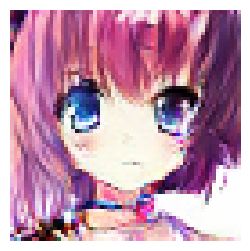

In [73]:
noise = tf.random.normal([1, 100])
fig = plt.figure(figsize=(3, 3))
# generate the image from noise
g_img = dcgan.generator(noise)
# denormalize the image
g_img = (g_img * 127.5) + 127.5
g_img.numpy()
img = array_to_img(g_img[0])
plt.imshow(img)
plt.axis('off')
# plt.savefig('epoch_{:03d}.png'.format(epoch))
plt.show()

Epoch 1/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - d_loss: 1.3912 - g_loss: 1.7440

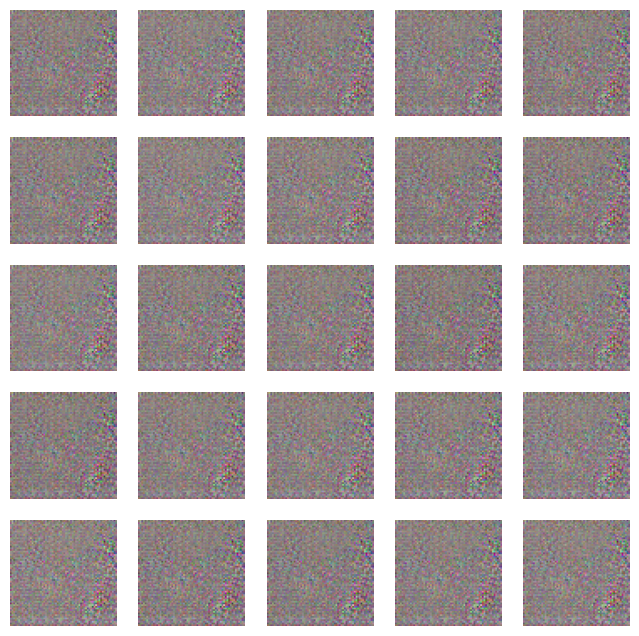

674/674 ━━━━━━━━━━━━━━━━━━━━ 210s 308ms/step - d_loss: 1.3902 - g_loss: 1.7453
Epoch 2/50
 46/674 ━━━━━━━━━━━━━━━━━━━━ 2:59 286ms/step - d_loss: -0.0110 - g_loss: 3.4801

KeyboardInterrupt: 

In [39]:
N_EPOCHS = 50
dcgan.fit(train_images, epochs=N_EPOCHS, callbacks=[DCGANMonitor()])